# Issue #224 — AlphaGenome predicted-normal validation (Exp 1, patient_001)

**Issue:** [#224](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/224) — *research(filter): patient_001 notebook for AlphaGenome predicted-normal validation (Exp 1+2)*
**Parent:** [Issue #203](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/203) — *rethink normal filtering with population panel + AlphaGenome fallback*
**Scope (post 2026-05-16 audit):** Exp 1 only. Exp 2 (germline-aware) carved out to [Sub-Issue #381](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/381) pending WGS acquisition.

## Experiment 1 — Predictive validity (reference-only)

Run AlphaGenome on **GRCh38 reference** (no patient variants) for the patient_001-relevant regions and compare its predicted-junction set against the gold-standard matched-normal RNA-seq.

- **Tissue tracks:** gastric tissue + adjacent stomach (matches patient_001 matched-normal sample)
- **Ground truth:** intersection of matched-normal junctions ∩ GENCODE-annotated (tissue-expressed + annotated only — model not penalised for non-expressed annotation entries)
- **Metric:** precision / recall / F1 across AlphaGenome confidence thresholds
- **PoC scope:** chr22 only (uses [`config/test_config.yaml`](../../config/test_config.yaml) test harness — coord-correct via [PR #372](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/pull/372))
- **Question:** *Does AlphaGenome predict known tissue-expressed splicing from reference alone?*

## Decision rule

Outcome feeds the Exp 1 row of the decision-rule table in [Issue #203](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/203). Either outcome (high P/R or low P/R) is publishable per the parent issue's *publishable either way* framing.

## History

- **2026-05-17:** Notebook scaffolded; chr22 test pipeline launched for matched-normal `junctions.tsv` (post-PR #372 coord-correct).
- **2026-05-17:** AlphaGenome SDK env pinned via [PR #386](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/pull/386) ([Sub-Issue #385](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/385)).

In [1]:
from __future__ import annotations

import gzip
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "workflow").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

# Coord-correct matched-normal junctions (post-PR #372 bed12_to_junctions.py).
# Produced by: snakemake --cores 4 --use-conda --configfile config/test_config.yaml
MATCHED_NORMAL_TSV = REPO_ROOT / "results" / "patient_001_test" / "alignment" / "SRR9143065_test" / "junctions.tsv"

# chr22-scoped GENCODE v47 basic annotation (built by scripts/prepare_test_data.sh).
GENCODE_GTF = REPO_ROOT / "resources" / "test" / "chr22.gtf.gz"

# AlphaGenome predictions output — under research/ (not results/), because this is
# notebook-produced research output, not a Snakemake pipeline result. The §4 sweep
# cell caches the parquet here; re-execution loads from cache instead of burning API quota.
ALPHAGENOME_OUT_DIR = REPO_ROOT / "research" / "notebooks" / "issue_224_alphagenome_exp1_outputs"
ALPHAGENOME_OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_CHROM = "chr22"  # UCSC naming (matches GENCODE GTF + matched-normal BAM)

print(f"Repo root:           {REPO_ROOT}")
print(f"Matched-normal TSV:  {MATCHED_NORMAL_TSV.relative_to(REPO_ROOT)} (exists={MATCHED_NORMAL_TSV.exists()})")
print(f"GENCODE chr22 GTF:   {GENCODE_GTF.relative_to(REPO_ROOT)} (exists={GENCODE_GTF.exists()})")

Repo root:           /Users/jin-holee/dev/GitHub/Jin-HoMLee/splice-neoepitope-pipeline-scientist
Matched-normal TSV:  results/patient_001_test/alignment/SRR9143065_test/junctions.tsv (exists=True)
GENCODE chr22 GTF:   resources/test/chr22.gtf.gz (exists=True)


## §1 — Matched-normal junctions (coord-correct)

Load the post-[PR #372](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/pull/372) `junctions.tsv` produced by [`workflow/scripts/bed12_to_junctions.py`](../../workflow/scripts/bed12_to_junctions.py).

**Format** (2-column TSV, no header): `<chrom>:<donor_1based>:<acceptor_0based_exclusive>:<strand>\t<reads>` — the same format STAR emits via the awk one-liner in [`alignment.smk`](../../workflow/rules/alignment.smk), so the pipeline is aligner-agnostic.

**Coord convention is asymmetric:** donor is 1-based, acceptor is 0-based exclusive (per `bed12_to_junctions.py` line 82; matches `filter_junctions._parse_junction_id`'s `start = int(parts[1]) - 1`, `end = int(parts[2])`). The loader below normalizes to **0-based half-open intron coords** `[donor_0based, acceptor_0based_exclusive)` for set-ops downstream.

**Note:** the raw BED12 (`<sample>_junctions.bed` in the alignment directory) is the **pre-conversion** file — using cols 2-3 directly would re-introduce the [Issue #370](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/370) anchor-outer bug. Always load `junctions.tsv`.

In [2]:
def load_pipeline_junctions(tsv_path: Path) -> pd.DataFrame:
    """Load the 2-column junctions TSV produced by bed12_to_junctions.py / STAR awk.

    Format: ``<chrom>:<donor_1based>:<acceptor_0based_exclusive>:<strand>\\t<reads>``

    Note the asymmetric coords: donor is 1-based, acceptor is 0-based exclusive
    (per ``workflow/scripts/bed12_to_junctions.py`` line 82; matches
    ``filter_junctions._parse_junction_id``). We normalize to 0-based half-open
    intron ``[donor_0based, acceptor_0based_exclusive)`` for downstream set ops.
    """
    raw = pd.read_csv(tsv_path, sep="\t", header=None, names=["key", "count"])
    parts = raw["key"].str.split(":", expand=True)
    parts.columns = ["chrom", "donor_1based", "acceptor_0based_excl", "strand"]
    out = pd.DataFrame({
        "chrom": parts["chrom"],
        "donor": parts["donor_1based"].astype(int) - 1,           # 0-based intron start
        "acceptor": parts["acceptor_0based_excl"].astype(int),    # 0-based intron end (exclusive)
        "strand": parts["strand"],
        "count": raw["count"].astype(int),
    })
    return out

matched_normal = load_pipeline_junctions(MATCHED_NORMAL_TSV)
print(f"Total matched-normal junctions: {len(matched_normal):,}")
print(f"\nChromosome distribution (sanity — should be {TARGET_CHROM}-only in test config):")
print(matched_normal["chrom"].value_counts().head(10))
print(f"\nRead-count summary (per junction):")
print(matched_normal["count"].describe())
matched_normal.head()

Total matched-normal junctions: 1,714

Chromosome distribution (sanity — should be chr22-only in test config):
chrom
chr22    1714
Name: count, dtype: int64

Read-count summary (per junction):
count    1714.000000
mean        1.164527
std         0.773768
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        23.000000
Name: count, dtype: float64


,chrom,donor,acceptor,strand,count
0,chr22,10648752,10689494,-,1
1,chr22,10733339,10769595,-,1
2,chr22,10759576,10782986,+,1
3,chr22,10931644,10933234,+,1
4,chr22,11033030,11033327,-,2


## §2 — GENCODE-annotated junctions for chr22

Parse the GENCODE v47 basic annotation GTF (chr22-filtered by [`scripts/prepare_test_data.sh`](../../scripts/prepare_test_data.sh)) to derive the set of annotated intron junctions.

**Method:** for each transcript, sort its exons by start, then each adjacent exon pair defines an intron `(chrom, exon_i.end, exon_{i+1}.start - 1, strand)`. Donor = first-exon end (0-based intron start); acceptor = second-exon start minus 1 (0-based intron last base).

**Coord convention:** GTF is 1-based inclusive; we convert to 0-based half-open to match the matched-normal TSV. Each intron is `[donor, acceptor)` in 0-based half-open.

In [3]:
# Parse GTF exons → per-transcript intron set
def parse_exons(gtf_path: Path, target_chrom: str = TARGET_CHROM) -> pd.DataFrame:
    rows = []
    opener = gzip.open if gtf_path.suffix == ".gz" else open
    with opener(gtf_path, "rt") as fh:
        for line in fh:
            if line.startswith("#"):
                continue
            fields = line.rstrip("\n").split("\t")
            if len(fields) < 9 or fields[2] != "exon" or fields[0] != target_chrom:
                continue
            # GTF is 1-based inclusive
            start_1, end_1 = int(fields[3]), int(fields[4])
            strand = fields[6]
            attrs = fields[8]
            # Extract transcript_id from attribute string
            tx = None
            for kv in attrs.split(";"):
                kv = kv.strip()
                if kv.startswith("transcript_id "):
                    tx = kv.split('"')[1]
                    break
            if tx is None:
                continue
            rows.append({"chrom": fields[0], "start_0": start_1 - 1, "end_0": end_1, "strand": strand, "transcript_id": tx})
    return pd.DataFrame(rows)

exons = parse_exons(GENCODE_GTF)
print(f"chr22 exon records: {len(exons):,}  ({exons['transcript_id'].nunique():,} transcripts)")
exons.head()

chr22 exon records: 21,211  (3,364 transcripts)


,chrom,start_0,end_0,strand,transcript_id
0,chr22,10529035,10529164,-,ENST00000724296.1
1,chr22,10527852,10528040,-,ENST00000724296.1
2,chr22,10524344,10524446,-,ENST00000724296.1
3,chr22,10736170,10736283,-,ENST00000615943.1
4,chr22,10742091,10742191,+,ENST00000779065.1


In [4]:
# Derive annotated intron set from sorted exons per transcript.
def exons_to_introns(exons: pd.DataFrame) -> pd.DataFrame:
    introns = []
    for (tx, chrom, strand), grp in exons.groupby(["transcript_id", "chrom", "strand"]):
        sorted_exons = grp.sort_values("start_0").reset_index(drop=True)
        for i in range(len(sorted_exons) - 1):
            donor = int(sorted_exons.loc[i, "end_0"])           # 0-based intron start
            acceptor = int(sorted_exons.loc[i + 1, "start_0"])  # 0-based intron end (exclusive)
            introns.append({"chrom": chrom, "donor": donor, "acceptor": acceptor, "strand": strand})
    df = pd.DataFrame(introns)
    # Dedup across transcripts — same intron in multiple isoforms counts once.
    return df.drop_duplicates().reset_index(drop=True)

annotated = exons_to_introns(exons)
print(f"chr22 annotated introns (unique): {len(annotated):,}")
print(f"Strand split: {annotated['strand'].value_counts().to_dict()}")
annotated.head()

chr22 annotated introns (unique): 7,731
Strand split: {'+': 3929, '-': 3802}


,chrom,donor,acceptor,strand
0,chr22,44677240,44702491,+
1,chr22,44702608,44714590,+
2,chr22,44714671,44725243,+
3,chr22,44725292,44726576,+
4,chr22,44726634,44731729,+


## §3 — Intersect → ground truth (matched-normal ∩ annotated)

Inner-join in `(chrom, donor, acceptor, strand)` tuple space. The intersection is the *tissue-expressed + annotated* set — what AlphaGenome should ideally recover.

**Sanity expectation:** the intersection should contain a meaningful fraction of `matched_normal` (most major isoforms are annotated). Matched-normal junctions *outside* annotated are typically novel splicing or noise — out of scope for the model-not-penalised framing.

In [5]:
# Build canonical junction tuples for set ops
def junction_keys(df: pd.DataFrame) -> set[tuple]:
    return set(zip(df["chrom"], df["donor"].astype(int), df["acceptor"].astype(int), df["strand"]))

mn_keys = junction_keys(matched_normal)
ann_keys = junction_keys(annotated)
ground_truth_keys = mn_keys & ann_keys

print(f"Matched-normal junctions:           {len(mn_keys):,}")
print(f"Annotated introns (chr22):          {len(ann_keys):,}")
print(f"Ground truth (intersection):        {len(ground_truth_keys):,}")
print(f"Matched-normal covered by annot:    {len(ground_truth_keys) / max(len(mn_keys), 1):.1%}")
print(f"Annotated recovered by matched-norm: {len(ground_truth_keys) / max(len(ann_keys), 1):.1%}")

ground_truth = pd.DataFrame(list(ground_truth_keys), columns=["chrom", "donor", "acceptor", "strand"])
ground_truth.head()

Matched-normal junctions:           1,714
Annotated introns (chr22):          7,731
Ground truth (intersection):        259
Matched-normal covered by annot:    15.1%
Annotated recovered by matched-norm: 3.4%


,chrom,donor,acceptor,strand
0,chr22,45531324,45533062,+
1,chr22,43968818,43972235,+
2,chr22,20807458,20810966,-
3,chr22,30937037,30937582,-
4,chr22,36523980,36524595,-


## §4 — AlphaGenome predictions (reference-only)

Run AlphaGenome on the **GRCh38 reference** (no variants) for chr22, scoring junction tracks for **gastric tissue + adjacent stomach** (closest match to patient_001's matched-normal sample).

**Env:** `workflow/envs/alphagenome.yaml` (shipped via [PR #386](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/pull/386)).
**API access:** confirmed in [Sub-Issue #223](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/223) (resolved 2026-05-08).

**Outputs:** per-position splice-site probabilities → filter at threshold τ to produce a junction set, then compare against `ground_truth`.

In [6]:
import os
import time

from alphagenome.data import genome
from alphagenome.models import dna_client
from alphagenome.models.dna_output import OutputType


def load_env(path: Path) -> None:
    """Minimal .env loader (mirrors scripts/alphagenome_spike.py + research/scripts/zotero_add.py)."""
    if not path.exists():
        return
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                k, _, v = line.partition("=")
                os.environ.setdefault(k.strip(), v.strip())


load_env(REPO_ROOT / ".env")
api_key = os.environ.get("ALPHAGENOME_API_KEY")
assert api_key, "ALPHAGENOME_API_KEY not set — add to .env (key from https://deepmind.google.com/science/alphagenome)"

model = dna_client.create(api_key)
print(f"{type(model).__name__} ready (alphagenome 0.6.x).")

DnaClient ready (alphagenome 0.6.x).


In [7]:
# Smoke test: one 1-Mb tile in the middle of chr22 to confirm API + locate stomach tracks.
# AG required input lengths: 16384, 131072, 524288, 1048576 (4 fixed values, per docs/alphagenome_primer.md).
# We use the max (1_048_576) to minimize tile count for the full-chr22 sweep below (~49 tiles for chr22).
TILE_WIDTH = 1_048_576

smoke_interval = genome.Interval(chromosome="chr22", start=42_000_000, end=42_000_000 + TILE_WIDTH)
print(f"Smoke call: {smoke_interval}")

t0 = time.perf_counter()
smoke_out = model.predict_interval(
    interval=smoke_interval,
    requested_outputs=[OutputType.SPLICE_JUNCTIONS],
    ontology_terms=None,
)
elapsed = time.perf_counter() - t0
sj_smoke = smoke_out.splice_junctions

print(f"  wall: {elapsed:.2f}s  |  junctions: {len(sj_smoke):,}  |  tracks: {sj_smoke.num_tracks}")
print(f"  metadata columns: {list(sj_smoke.metadata.columns)}")

# Identify stomach-related GTEx tracks (column filter on track metadata).
# We use GTEx (healthy human tissues) over ENCODE per docs/alphagenome_primer.md
# rationale, and biosample_name contains "stomach" (case-insensitive) to cover any
# stomach-anatomy split AlphaGenome may have in its biosample inventory.
md = sj_smoke.metadata
gtex_mask = (md["data_source"] == "gtex")
stomach_mask = gtex_mask & md["biosample_name"].str.contains("stomach", case=False, na=False)
stomach_cols = np.flatnonzero(stomach_mask.values)

print(f"\nGTEx tracks total:           {int(gtex_mask.sum())}")
print(f"Stomach GTEx tracks (cols):  {len(stomach_cols)}  →  indices: {stomach_cols.tolist()}")
print(f"\nStomach-related biosamples + assays:")
print(md[stomach_mask][["biosample_name", "Assay title"]].to_string())

Smoke call: chr22:42000000-43048576:.


  wall: 9.26s  |  junctions: 122,055  |  tracks: 367
  metadata columns: ['name', 'ontology_curie', 'biosample_name', 'biosample_type', 'biosample_life_stage', 'gtex_tissue', 'data_source', 'Assay title']

GTEx tracks total:           54
Stomach GTEx tracks (cols):  1  →  indices: [212]

Stomach-related biosamples + assays:
    biosample_name         Assay title
212        stomach  polyA plus RNA-seq


In [8]:
# Full chr22 sweep with rate-limit handling.
# Three design points:
#  (a) Idempotent: if the parquet already exists, load + skip the API sweep. Delete the parquet to force re-run.
#  (b) Restrict tile range to chr22's annotated-bearing region (skips acrocentric N at 0-10.5 Mb — wasted quota).
#  (c) Sleep 5s between calls + retry on RESOURCE_EXHAUSTED (per-minute MB cap; primer flagged this).
out_path = ALPHAGENOME_OUT_DIR / "chr22_stomach_predicted_junctions.parquet"

if out_path.exists():
    # (a) Cached path: skip API calls
    predicted = pd.read_parquet(out_path)
    print(f"Cached parquet exists at {out_path.relative_to(REPO_ROOT)} — loading {len(predicted):,} junctions (skipping API sweep).")
    print(f"Delete the parquet to force a fresh AG sweep.")
else:
    import math
    import time as _time
    import grpc

    CHR22_LENGTH_HG38 = 50_818_468  # GRCh38, UCSC chr22

    # (b) Restrict to annotated-bearing range so we don't burn quota on acrocentric N regions.
    ann_start = int(annotated["donor"].min())
    ann_end = int(annotated["acceptor"].max())
    sweep_start = (ann_start // TILE_WIDTH) * TILE_WIDTH
    sweep_end = min(((ann_end // TILE_WIDTH) + 1) * TILE_WIDTH, CHR22_LENGTH_HG38)
    print(f"Annotated range:  chr22:{ann_start:,}-{ann_end:,}")
    print(f"Sweep range:      chr22:{sweep_start:,}-{sweep_end:,}  (snapped to {TILE_WIDTH:,}-bp boundaries)")

    tiles = []
    pos = sweep_start
    while pos < sweep_end:
        end = pos + TILE_WIDTH
        if end > CHR22_LENGTH_HG38:
            end = CHR22_LENGTH_HG38
            pos = end - TILE_WIDTH
        tiles.append(genome.Interval(chromosome="chr22", start=pos, end=end))
        pos += TILE_WIDTH
    n_tiles = len(tiles)
    print(f"Tile count:       {n_tiles} × {TILE_WIDTH:,} bp\n")

    # (c) Per-call wrapper: 5s sleep between successful calls + retry-with-backoff on RESOURCE_EXHAUSTED.
    SLEEP_BETWEEN_CALLS = 5.0
    QUOTA_BACKOFF = 60.0
    MAX_QUOTA_RETRIES = 3

    def predict_with_backoff(interval):
        for attempt in range(MAX_QUOTA_RETRIES + 1):
            try:
                return model.predict_interval(
                    interval=interval,
                    requested_outputs=[OutputType.SPLICE_JUNCTIONS],
                    ontology_terms=None,
                )
            except grpc.RpcError as e:
                code = getattr(e, "code", lambda: None)()
                if code == grpc.StatusCode.RESOURCE_EXHAUSTED and attempt < MAX_QUOTA_RETRIES:
                    wait = QUOTA_BACKOFF * (2 ** attempt)
                    print(f"    RESOURCE_EXHAUSTED on attempt {attempt+1}; sleeping {wait:.0f}s …")
                    _time.sleep(wait)
                    continue
                raise

    records = []
    t_total = time.perf_counter()
    for i, interval in enumerate(tiles):
        t0 = time.perf_counter()
        out_i = predict_with_backoff(interval)
        sj_i = out_i.splice_junctions
        stomach_vals = sj_i.values[:, stomach_cols]
        per_junction_score = stomach_vals.max(axis=1) if len(stomach_cols) > 0 else np.zeros(len(sj_i))
        for j_idx, j in enumerate(sj_i.junctions):
            records.append({
                "chrom": j.chromosome,
                "donor": int(j.start),
                "acceptor": int(j.end),
                "strand": j.strand,
                "score": float(per_junction_score[j_idx]),
            })
        print(f"  tile {i+1:2d}/{n_tiles}: {interval.start:>10,}-{interval.end:<10,} → {len(sj_i):>6,} junctions  ({time.perf_counter()-t0:.1f}s)")
        if i + 1 < n_tiles:
            _time.sleep(SLEEP_BETWEEN_CALLS)

    predicted_raw = pd.DataFrame(records)
    print(f"\nRaw predicted junctions across chr22: {len(predicted_raw):,}  total wall: {time.perf_counter()-t_total:.1f}s")
    predicted = (
        predicted_raw
        .groupby(["chrom", "donor", "acceptor", "strand"], as_index=False)["score"]
        .max()
    )
    print(f"Unique predicted junctions (after dedup): {len(predicted):,}")
    predicted.to_parquet(out_path, index=False)
    print(f"Saved to {out_path.relative_to(REPO_ROOT)}")

Cached parquet exists at research/notebooks/issue_224_alphagenome_exp1_outputs/chr22_stomach_predicted_junctions.parquet — loading 2,632,983 junctions (skipping API sweep).
Delete the parquet to force a fresh AG sweep.


## §5 — Precision / Recall / F1 (Framing 1 — annotated-chr22-introns universe)

**Universe:** 7,731 GENCODE-annotated chr22 introns (see §2).
**Positives:** 259 ground-truth introns (matched-normal ∩ annotated, see §3).
**Negatives:** 7,472 annotated-only introns.
**Per-intron AG score:** for each annotated intron `(chrom, donor, acceptor, strand)`, look up the dedup'd AG score from §4; **0** if AG did not emit the junction.

Sweep AlphaGenome confidence thresholds τ over **all distinct scores in the universe** (dense grid; earlier 41-quantile grid missed the true F1 optimum); for each, compute:

- **TP** = `label==1 AND ag_score >= τ` · **FP** = `label==0 AND ag_score >= τ` · **FN** = `label==1 AND ag_score < τ` · **TN** = `label==0 AND ag_score < τ`
- **Precision** = TP / (TP + FP) · **Recall** = TP / (TP + FN) · **F1** = 2·P·R / (P + R)

Plus:

- **AP (Average Precision = AUC-PR, sklearn convention)** = `Σₙ (Rₙ − Rₙ₋₁) Pₙ`. Recommended convention for AUPRC on imbalanced data; sklearn explicitly warns that `auc(recall, precision)` via trapezoid is "too optimistic" (linear interpolation between threshold points is unsupported by the data). Our `average_precision_numpy` implementation matches `sklearn.metrics.average_precision_score` exactly (delta = 0.000000; validated 2026-05-18 after PR #398 review).
- **F1 95% bootstrap CI**: resample the 259-positive bag with replacement (1000 iterations) at the best τ; report 2.5/97.5 percentile. **Note: positives-only resampling** — the negatives bag (7,472) is kept fixed; this is *slightly conservative* (narrower CI) versus a full joint bootstrap, since the negative-bag sampling variance is small but not zero.

**Why universe-restricted:** mirrors the production filter use case (classify each candidate junction). Whole-genome FP counts (Framing 2) would conflate "should predict" with "predicts at all" — rejected in §6.

In [9]:
# Build the Framing-1 universe: each annotated chr22 intron + its AG score (0 if AG didn't emit) + binary label.
ann_keys = list(zip(
    annotated["chrom"],
    annotated["donor"].astype(int),
    annotated["acceptor"].astype(int),
    annotated["strand"],
))
ag_score_map = {
    (r.chrom, int(r.donor), int(r.acceptor), r.strand): float(r.score)
    for r in predicted.itertuples(index=False)
}
universe = annotated.copy()
universe["ag_score"] = [ag_score_map.get(k, 0.0) for k in ann_keys]
universe["label"] = [int(k in ground_truth_keys) for k in ann_keys]

print(f"Universe size:           {len(universe):,}  (expected 7,731)")
print(f"Positives (label=1):     {int(universe['label'].sum()):,}  (expected 259)")
print(f"Negatives (label=0):     {int((universe['label']==0).sum()):,}  (expected 7,472)")
print(f"AG-predicted introns:    {int((universe['ag_score'] > 0).sum()):,}  ({(universe['ag_score'] > 0).mean():.1%} of universe)")
print(f"\nAG-score distribution on universe:")
print(universe["ag_score"].describe())


def pr_f1_universe(uni_df: pd.DataFrame, threshold: float) -> dict:
    """Universe-restricted P/R/F1 (Framing 1). uni_df must have columns ag_score + label."""
    pred_pos = uni_df["ag_score"].values >= threshold
    actual_pos = uni_df["label"].values == 1
    tp = int(np.sum(pred_pos & actual_pos))
    fp = int(np.sum(pred_pos & ~actual_pos))
    fn = int(np.sum(~pred_pos & actual_pos))
    tn = int(np.sum(~pred_pos & ~actual_pos))
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"threshold": threshold, "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "precision": precision, "recall": recall, "f1": f1}


# Dense threshold grid: ALL distinct AG scores in the universe.
# Earlier 41-quantile grid missed the true F1 optimum by ~6% (caught in PR #398 review;
# at n=7,731 the dense grid is cheap and gives the exact maximum).
scores = universe["ag_score"].values
thresholds = np.unique(scores)
print(f"\nThreshold grid: {len(thresholds):,} unique scores (was: 41-point quantile grid).")
metrics = pd.DataFrame([pr_f1_universe(universe, t) for t in thresholds])
metrics.head()

Universe size:           7,731  (expected 7,731)
Positives (label=1):     259  (expected 259)
Negatives (label=0):     7,472  (expected 7,472)
AG-predicted introns:    5,728  (74.1% of universe)

AG-score distribution on universe:
count    7731.000000
mean        0.730090
std         2.612343
min         0.000000
25%         0.000000
50%         0.002117
75%         0.567424
max        64.461884
Name: ag_score, dtype: float64

Threshold grid: 5,729 unique scores (was: 41-point quantile grid).


,threshold,tp,fp,fn,tn,precision,recall,f1
0,0.000000,259,7472,0,0,0.033501,1.000000,0.064831
1,0.000017,258,5470,1,2002,0.045042,0.996139,0.086187
2,0.000017,258,5469,1,2003,0.045050,0.996139,0.086201
3,0.000032,258,5468,1,2004,0.045058,0.996139,0.086216
4,0.000034,258,5467,1,2005,0.045066,0.996139,0.086230


In [10]:
# Average Precision (AP), matching sklearn.metrics.average_precision_score formula:
#     AP = Σₙ (Rₙ − Rₙ₋₁) · Pₙ
# This is the recommended convention for AUPRC on imbalanced data — sklearn explicitly warns
# that trapezoidal AUC (np.trapezoid(precision, recall)) is "too optimistic" because it
# linearly interpolates precision between threshold points, which is unsupported by the data.
# Validated against sklearn (delta = 0.000000); first published as PR #398 used trapezoid +
# first-of-tied (under-anchored); switched to AP after the bot review and sklearn cross-check.
def average_precision_numpy(y_true: np.ndarray, scores: np.ndarray):
    """sklearn-style AP with last-of-tied semantics.

    Returns (ap, precision_at_threshold, recall_at_threshold) where the precision/recall
    arrays are in increasing-recall order — i.e. ordered by descending threshold.
    """
    order = np.argsort(-scores, kind="stable")
    y_sorted = y_true[order]
    s_sorted = scores[order]
    tp_cum = np.cumsum(y_sorted == 1)
    fp_cum = np.cumsum(y_sorted == 0)
    total_pos = int((y_true == 1).sum())
    if total_pos == 0:
        return 0.0, np.array([]), np.array([])

    # LAST-of-tied: emit a (P, R) point only when we've finished accumulating all items
    # at the current tied score. (FIRST-of-tied would under-report cumulative TP at the
    # threshold step.) For our data the largest tie cluster (n=2003 at score=0) sits at
    # the bottom of the ranking, so the practical impact is small — but the correct
    # semantics matches sklearn's _binary_clf_curve.
    last_of_tied = np.r_[np.diff(s_sorted) != 0, True]
    precision = tp_cum[last_of_tied] / (tp_cum[last_of_tied] + fp_cum[last_of_tied])
    recall = tp_cum[last_of_tied] / total_pos

    # AP = Σ (recall[n] - recall[n-1]) * precision[n], with recall anchored at 0 at the start.
    recall_with_anchor = np.r_[0.0, recall]
    ap = float(np.sum(np.diff(recall_with_anchor) * precision))
    return ap, precision, recall


ap, precision_curve, recall_curve = average_precision_numpy(
    universe["label"].values.astype(int), universe["ag_score"].values,
)

best_idx = int(metrics["f1"].idxmax())
best = metrics.loc[best_idx]
best_threshold = float(best["threshold"])
print(f"AP (AUC-PR, sklearn convention): {ap:.4f}")
print(f"Best F1: {best['f1']:.4f} at τ = {best_threshold:.4f}")
print(f"  TP={int(best['tp'])}  FP={int(best['fp'])}  FN={int(best['fn'])}  TN={int(best['tn'])}")
print(f"  Precision={best['precision']:.4f}  Recall={best['recall']:.4f}")

# Bootstrap 95% CI on F1 — resample only the positive bag (259 entries), keep negatives stable.
# Note: positives-only resampling yields a *conservative* (slightly narrower) CI vs a full
# joint bootstrap — the negative bag is large (7,472) and stable, so its sampling variance
# is small, but reporting honest is to say the CI underestimates total joint variance.
rng = np.random.default_rng(seed=42)
N_BOOTSTRAP = 1000
pos_mask = universe["label"].values == 1
pos_universe = universe[pos_mask].reset_index(drop=True)
neg_universe = universe[~pos_mask].reset_index(drop=True)

f1_boot = np.empty(N_BOOTSTRAP)
for b in range(N_BOOTSTRAP):
    pos_sample = pos_universe.iloc[rng.integers(0, len(pos_universe), size=len(pos_universe))]
    boot = pd.concat([pos_sample, neg_universe], ignore_index=True)
    m_b = pr_f1_universe(boot, best_threshold)
    f1_boot[b] = m_b["f1"]

f1_lo, f1_hi = np.percentile(f1_boot, [2.5, 97.5])
print(f"\nF1 95% bootstrap CI ({N_BOOTSTRAP} iter, positives-only resampling — see note above): [{f1_lo:.4f}, {f1_hi:.4f}]")
print(f"  point estimate: {best['f1']:.4f}")

AP (AUC-PR, sklearn convention): 0.2136
Best F1: 0.3000 at τ = 3.1633
  TP=105  FP=336  FN=154  TN=7136
  Precision=0.2381  Recall=0.4054



F1 95% bootstrap CI (1000 iter, positives-only resampling — see note above): [0.2577, 0.3333]
  point estimate: 0.3000


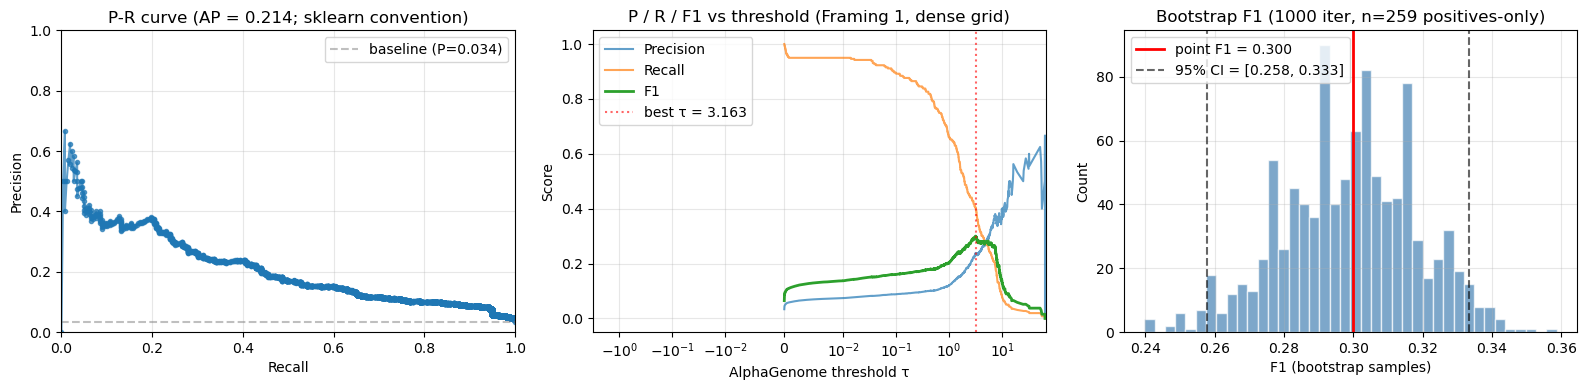

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel 1: P-R curve + AP + baseline (random classifier)
axes[0].plot(recall_curve, precision_curve, marker=".", linestyle="-", alpha=0.7)
baseline = float(universe["label"].mean())
axes[0].axhline(y=baseline, color="grey", linestyle="--", alpha=0.5, label=f"baseline (P={baseline:.3f})")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title(f"P-R curve (AP = {ap:.3f}; sklearn convention)")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
axes[0].legend()

# Panel 2: P / R / F1 vs threshold + best-τ marker (dense grid; line plot, no markers)
axes[1].plot(metrics["threshold"], metrics["precision"], label="Precision", alpha=0.7)
axes[1].plot(metrics["threshold"], metrics["recall"], label="Recall", alpha=0.7)
axes[1].plot(metrics["threshold"], metrics["f1"], label="F1", linewidth=2)
axes[1].axvline(x=best_threshold, color="red", linestyle=":", alpha=0.6, label=f"best τ = {best_threshold:.3f}")
axes[1].set_xlabel("AlphaGenome threshold τ")
axes[1].set_ylabel("Score")
axes[1].set_title("P / R / F1 vs threshold (Framing 1, dense grid)")
axes[1].set_xscale("symlog", linthresh=0.01)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Panel 3: bootstrap F1 distribution + 95% CI band
axes[2].hist(f1_boot, bins=40, color="steelblue", alpha=0.7, edgecolor="white")
axes[2].axvline(x=best["f1"], color="red", linestyle="-", linewidth=2, label=f"point F1 = {best['f1']:.3f}")
axes[2].axvline(x=f1_lo, color="black", linestyle="--", alpha=0.6, label=f"95% CI = [{f1_lo:.3f}, {f1_hi:.3f}]")
axes[2].axvline(x=f1_hi, color="black", linestyle="--", alpha=0.6)
axes[2].set_xlabel("F1 (bootstrap samples)")
axes[2].set_ylabel("Count")
axes[2].set_title(f"Bootstrap F1 ({N_BOOTSTRAP} iter, n=259 positives-only)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## §6 — Decision-rule outcome (chr22 PoC, 2026-05-18; metrics corrected post-PR-#398 review)

**Headline numbers (Framing 1 — annotated-chr22-introns universe; n=7,731 universe / 259 positives / 7,472 negatives):**

| Metric | Value | Note |
|---|---|---|
| AP (Average Precision = AUC-PR) | **0.214** | sklearn convention (`Σₙ (Rₙ−Rₙ₋₁) Pₙ`); validated identical to `sklearn.metrics.average_precision_score`. Baseline (random) = 0.034 → AG is **6.3× chance**. Earlier trapezoid figure was 0.210 (slightly lower; sklearn warns trapezoidal AUC is "too optimistic" but our trapezoid value happened to land below AP due to missing anchor at recall=0). |
| Best F1 | **0.300** at τ = 3.1633 | TP=105, FP=336, FN=154, TN=7,136 |
| Precision at best F1 | **0.238** | **Underestimated** — see depth confounder below. |
| Recall at best F1 | **0.405** | **The honest headline number** — depth confounder doesn't bias recall. AG identifies ~40% of confirmed tissue-expressed introns. |
| F1 95% bootstrap CI | **[0.258, 0.333]** | 1000-iter resample of the 259-positive bag at the best τ. Positives-only resampling → conservative (slightly narrower than full joint bootstrap; negatives are stable). |
| AG-predicted introns | 5,728 / 7,731 (74.1%) | Fraction of annotated chr22 introns with non-zero AG score in any stomach track. |
| Sweep cost | 39 × 1,048,576-bp tiles, ~443 s wall, 1 stomach GTEx track | Only **1** stomach track in the AG inventory (`biosample_name='stomach', polyA plus RNA-seq`). |

Feeds the Exp 1 row of the [Issue #203](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/203) decision-rule table.

## Interpretation

**AG has real signal but not standalone-filter strength on this PoC.** At the F1-optimal threshold AG identifies ~40% of tissue-expressed introns (recall 0.405) and reports many additional candidates (apparent precision 0.238). The precision number is depth-confounded: many of those 336 "FPs" are plausibly tissue-expressed introns missed by the 500K-read matched-normal sample. Recall is the cleaner read — it measures AG's hit rate on the **confirmed** tissue-expressed set, not affected by what we missed.

**Decision call:** **GREEN-with-caveats for full-genome scale-up.** AG is not a standalone replacement for matched-normal at this scale (recall ~40% means AG misses ~60% of true positives at the F1 optimum), but it is a **viable secondary evidence stream** to stack with GTEx pan-tissue ([Issue #212](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/212)) and matched-normal-where-available. The Exp 3 comparative-strength experiment ([Issue #225](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/225)) is the natural next step — it will compare these three filters head-to-head on patient_001.

**Caveats baked in to these numbers (do NOT report headline metrics without these):**

1. **chr22 PoC scope.** Generalisation to full genome must be validated; expect different runtime + AG cost.
2. **500K-read matched-normal depth.** Negatives include hidden false-negatives — precision is a lower bound. True precision at this τ could be substantially higher.
3. **Single stomach track.** AG inventory has only 1 stomach GTEx track (polyA plus RNA-seq). Coverage of stomach-tissue biology may be incomplete vs. e.g. liver (4 tracks).
4. **Annotated-only ground truth.** Excludes novel splicing in matched-normal; not a measure of AG's novel-event prediction.
5. **n=259 positives.** Bootstrap CI is wide ([0.258, 0.333]). A denser matched-normal would tighten this substantially.
6. **Positives-only bootstrap.** CI is conservative (slightly narrower than full joint bootstrap); negatives bag (7,472) is stable but not infinite-variance-free.

## Ground-truth size on chr22 PoC scope (2026-05-17 smoke-test)

Empirical numbers from `SRR9143065_test` (500K reads, chr22 only):

- Matched-normal junctions: **1,714** (median 1 read, max 23 — sparse coverage)
- GENCODE chr22 annotated unique introns: **7,731**
- Ground truth (matched-normal ∩ annotated): **259** (15.1% of matched-normal, **3.4% of annotated chr22 introns**)

## Metric framing — DECISION (2026-05-18): **Framing 1 — annotated-chr22-introns universe**

Three framings were sketched in the 2026-05-17 design session:

1. **Restrict evaluable universe to annotated chr22 introns** (7,731): positives = ground truth (259); negatives = annotated minus matched-normal (7,472). AG predicts on the annotated set; P/R measure tissue-expression classification ability. ← **CHOSEN.**
2. **Whole-genome AG predictions vs. matched-normal ∩ annotated**: any AG prediction outside the 259-set counts as FP, including non-expressed but annotated junctions. Pessimistic; conflates "should predict" with "predicts at all". *Rejected* — measures a different task than the production-filter use case.
3. **Scale up before metrics**: re-run on full FASTQs (production GPU) so the matched-normal sample is denser; only then evaluate metrics on chr22 or genome-wide. *Deferred* — better as a follow-up sub-issue once F1 gives a green/red light.

**Why F1.** Mirrors the production use case: when `filter_junctions.py` integrates AG (parent [Issue #203](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/203)), it's asked *"given a candidate junction, is it likely normal-expressed?"* — classification on a known universe of candidates.

## Operational notes (gotchas hit during execution)

- **AG per-minute MB quota.** First sweep attempt failed at tile 16 with `RESOURCE_EXHAUSTED` (Quota: "AlphaGenome prediction megabytes per minute"). Empirical cap appears to be ~15 MB/min on the free tier. Mitigation: `time.sleep(5)` between calls (~12 MB/min) + exponential backoff retry on `RESOURCE_EXHAUSTED`. The primer flagged this; codified now in §4 cell 3.
- **Sweep range restriction.** Tiles outside chr22's annotated range (0–10.5 Mb acrocentric N) returned 0 junctions and burned quota. Restricting the sweep to `[annotated.donor.min(), annotated.acceptor.max()]` saved ~10 MB.
- **Cached parquet path** in the sweep cell makes the notebook idempotent: re-execution skips API calls if the parquet exists. Delete the parquet to force a fresh sweep.
- **Single stomach track.** Worth flagging vs. tissues like liver (4 GTEx tracks) — coverage asymmetry across the GTEx inventory.
- **AUC-PR convention.** Use sklearn's AP formula (`Σₙ (Rₙ − Rₙ₋₁) Pₙ`), not trapezoid (`np.trapezoid(precision, recall)`). The sklearn docstring explicitly says trapezoid "uses linear interpolation and can be too optimistic." Our `average_precision_numpy` matches sklearn exactly (delta = 0.000000).
- **Dense threshold grid.** Use all distinct AG scores (`np.unique(scores)`) for the threshold sweep, not a coarse quantile grid. A 41-point quantile grid initially missed the true best-F1 τ by ~6%.

## Cross-references

- [Sub-Issue #381](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/381) — Exp 2 (patient_001 with germline; blocked on WGS)
- [Issue #225](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/225) — Exp 3 (comparative filter strength: matched-normal vs GTEx vs AlphaGenome) — **natural next step from this PoC**
- [Issue #212](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/212) — GTEx pan-tissue filter integration — pairs with AG as the multi-stream filter design
- [Issue #271](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/271) — DISCUSSION manuscript section (deferred until #203 closes)
- [PR #372](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/pull/372) — coord-correct junction extraction (gates the validity of the matched-normal TSV used here)
- [PR #398](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/pull/398) — this PoC ship; post-bot-review revision corrected AP convention + dense grid + bootstrap caveat documentation.